In [33]:
import sys
import os

current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

## **Data Check**

In [ ]:
import os

RAW_DATA_PATH = '../data/raw/'

def list_files_tree(startpath):
    print(f"--- DIRECTORY STRUCTURE: {startpath} ---")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print('{}{}'.format(subindent, f))

list_files_tree(RAW_DATA_PATH)

--- DIRECTORY STRUCTURE: ../data/raw/ ---
/
    application_test.csv
    application_train.csv
    bureau.csv
    bureau_balance.csv
    credit_card_balance.csv
    HomeCredit_columns_description.csv
    installments_payments.csv
    POS_CASH_balance.csv
    previous_application.csv
    sample_submission.csv


In [1]:
import os
import pandas as pd

# Configuration
RAW_DATA_PATH = '../data/raw/'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

def inspect_data_inventory(path):
    # List all CSV files
    try:
        files = [f for f in os.listdir(path) if f.endswith('.csv')]
    except FileNotFoundError:
        print(f"[ERROR] Directory not found: {path}")
        return

    print(f"--- DATA INVENTORY REPORT ({len(files)} files detected) ---")
    print(f"Path: {path}\n")

    for file in files:
        file_path = os.path.join(path, file)
        try:
            # Read only the first 3 rows for quick inspection
            df_preview = pd.read_csv(file_path, nrows=3)
            
            print(f"[FILE] {file}")
            print(f"   Shape (Rows, Cols): {df_preview.shape}")
                        
            # Column Check for Identification
            cols = df_preview.columns.tolist()
            
            # Check for GMSC Target
            if 'SeriousDlqin2yrs' in cols:
                print("   [TYPE] Give Me Some Credit (GMSC) Dataset")
                print("   [ROLE] Potential Base Table (Target Found)")
            
            # Check for Home Credit Target
            elif 'TARGET' in cols:
                print("   [TYPE] Home Credit Default Risk (HCDR) Dataset")
                print("   [ROLE] Potential Base Table (Target Found)")
            
            # Check for IDs
            elif 'SK_ID_CURR' in cols:
                print("   [TYPE] Home Credit Auxiliary Table")
                print("   [ROLE] Feature Table (Join required via SK_ID_CURR)")
            
            else:
                print("   [TYPE] Unknown / Other")
            
            print(f"   Columns: {cols[:500]} ...") 
            print("-" * 60)
            
        except Exception as e:
            print(f"[ERROR] Could not read {file}: {e}")
            print("-" * 60)

# Execute the inspection
inspect_data_inventory(RAW_DATA_PATH)

--- DATA INVENTORY REPORT (10 files detected) ---
Path: ../data/raw/

[FILE] application_test.csv
   Shape (Rows, Cols): (3, 121)
   [TYPE] Home Credit Auxiliary Table
   [ROLE] Feature Table (Join required via SK_ID_CURR)
   Columns: ['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CI

In [2]:
import os
import pandas as pd
from IPython.display import display

RAW_DATA_PATH = '../data/raw/'
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

def preview_all_datasets(path):
    # Check if directory exists
    if not os.path.exists(path):
        print(f"[ERROR] Directory not found: {path}")
        return

    # List CSV files
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    if not files:
        print("[WARNING] No CSV files found in the directory.")
        return

    print(f"--- DATA CONTENT INSPECTION ({len(files)} files) ---\n")

    for file in files:
        file_path = os.path.join(path, file)
        try:
            df_preview = pd.read_csv(file_path, nrows=5)
            
            print(f"[FILE] {file}")
            print(f"[SHAPE PREVIEW] {df_preview.shape}")
            
            if 'SeriousDlqin2yrs' in df_preview.columns:
                print("[INFO] Target Variable Detected: 'SeriousDlqin2yrs' (GMSC)")
            elif 'TARGET' in df_preview.columns:
                print("[INFO] Target Variable Detected: 'TARGET' (Home Credit)")
            
            # Render the DataFrame
            display(df_preview.head())
            
            print("-" * 100)
            print("\n")
            
        except Exception as e:
            print(f"[ERROR] Failed to read {file}: {e}")

preview_all_datasets(RAW_DATA_PATH)

--- DATA CONTENT INSPECTION (10 files) ---

[FILE] application_test.csv
[SHAPE PREVIEW] (5, 121)
[INFO] Key Variable Detected: 'SK_ID_CURR' (Auxiliary Table)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

----------------------------------------------------------------------------------------------------


[FILE] application_train.csv
[SHAPE PREVIEW] (5, 122)
[INFO] Target Variable Detected: 'TARGET' (Home Credit)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

----------------------------------------------------------------------------------------------------


[FILE] bureau.csv
[SHAPE PREVIEW] (5, 17)
[INFO] Key Variable Detected: 'SK_ID_CURR' (Auxiliary Table)


...

----------------------------------------------------------------------------------------------------


[FILE] previous_application.csv
[SHAPE PREVIEW] (5, 37)
[INFO] Key Variable Detected: 'SK_ID_CURR' (Auxiliary Table)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------


[FILE] sample_submission.csv
[SHAPE PREVIEW] (5, 2)
[INFO] Target Variable Detected: 'TARGET' (Home Credit)


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5


----------------------------------------------------------------------------------------------------




## **Train, Test (Val) Split**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

RAW_DATA_PATH = '../data/raw/application_train.csv'
PROCESSED_DATA_PATH = '../data/processed/'

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print("Loading data...")
df = pd.read_csv(RAW_DATA_PATH)

# 2. Siddiqi Principle: Stratified Split
# In credit risk, "Defaults" (~8%) are the minority class.
# Random splitting might result in a Test set with very few or no defaults.
# By using "stratify=y", we preserve the 8% default rate in both Train and Test sets.

X = df.drop(columns=['TARGET'])
y = df['TARGET']

print("Splitting data (70% Train / 30% Test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("Saving split datasets...")
train_df.to_csv(os.path.join(PROCESSED_DATA_PATH, 'application_train_SPLIT.csv'), index=False)
test_df.to_csv(os.path.join(PROCESSED_DATA_PATH, 'application_test_SPLIT.csv'), index=False)

print("-" * 30)
print(f"Original Data Count   : {df.shape[0]} rows")
print(f"Train Set             : {train_df.shape[0]} rows (70%)")
print(f"Test Set (Validation) : {test_df.shape[0]} rows (30%)")
print("-" * 30)
print("Target Distribution Check (Stratification Verification):")
print(f"Original Default Rate : {df['TARGET'].mean()*100:.2f}%")
print(f"Train Default Rate    : {train_df['TARGET'].mean()*100:.2f}%")
print(f"Test Default Rate     : {test_df['TARGET'].mean()*100:.2f}%")
print("-" * 30)

Loading data...
Splitting data (70% Train / 30% Test)...
Saving split datasets...
------------------------------
Original Data Count   : 307511 rows
Train Set             : 215257 rows (70%)
Test Set (Validation) : 92254 rows (30%)
------------------------------
Target Distribution Check (Stratification Verification):
Original Default Rate : 8.07%
Train Default Rate    : 8.07%
Test Default Rate     : 8.07%
------------------------------


## **Aggregation & Feature Engineering**

In [10]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

### bureau_balance

In [12]:
from src.preprocessing import get_column_descriptions

bureau_metadata = get_column_descriptions('bureau_balance.csv')
display(bureau_metadata)

,Row,Description,Special
139,SK_BUREAU_ID,Recoded ID of Credit Bureau credit (unique coding for each application) - use this to join to CREDIT_BUREAU table,hashed
140,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application
141,STATUS,"Status of Credit Bureau loan during the month (active, closed, DPD0-30, [C means closed, X means status unknown, 0 means no DPD, 1 means maximal did during month between 1-30, 2 means DPD 31-60, 5 means DPD 120+ or sold or written off ] )",NaN


In [ ]:
import pandas as pd
from src.aggregation import get_bureau_balance_status_dummies, get_bb_agg_logic, aggregate_bureau_balance

bb = pd.read_csv('../data/raw/bureau_balance.csv')

In [ ]:
bb_encoded = get_bureau_balance_status_dummies(bb)
display(bb_encoded.head())

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS_0,STATUS_1,STATUS_2,STATUS_3,STATUS_4,STATUS_5,STATUS_C,STATUS_X
0,5715448,0,False,False,False,False,False,False,True,False
1,5715448,-1,False,False,False,False,False,False,True,False
2,5715448,-2,False,False,False,False,False,False,True,False
3,5715448,-3,False,False,False,False,False,False,True,False
4,5715448,-4,False,False,False,False,False,False,True,False


In [18]:
# Define the risk-based logic
logic = get_bb_agg_logic(bb_encoded)

bb_final = aggregate_bureau_balance(bb_encoded, logic)

print(f"Aggregation complete. Final shape: {bb_final.shape}")
display(bb_final.head())

Aggregation complete. Final shape: (817395, 20)


,SK_ID_BUREAU,BB_MONTHS_BALANCE_MIN,BB_MONTHS_BALANCE_MAX,BB_MONTHS_BALANCE_SIZE,BB_STATUS_0_MEAN,BB_STATUS_0_SUM,BB_STATUS_1_MEAN,BB_STATUS_1_SUM,BB_STATUS_2_MEAN,BB_STATUS_2_SUM,BB_STATUS_3_MEAN,BB_STATUS_3_SUM,BB_STATUS_4_MEAN,BB_STATUS_4_SUM,BB_STATUS_5_MEAN,BB_STATUS_5_SUM,BB_STATUS_C_MEAN,BB_STATUS_C_SUM,BB_STATUS_X_MEAN,BB_STATUS_X_SUM
0,5001709,-96,0,97,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.886598,86,0.113402,11
1,5001710,-82,0,83,0.060241,5,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.578313,48,0.361446,30
2,5001711,-3,0,4,0.750000,3,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,0.250000,1
3,5001712,-18,0,19,0.526316,10,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.473684,9,0.000000,0
4,5001713,-21,0,22,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,1.000000,22


### bureau

In [80]:
from src.preprocessing import get_column_descriptions

bureau_metadata = get_column_descriptions('bureau.csv')
display(bureau_metadata)

,Row,Description,Special
122,SK_ID_CURR,"ID of loan in our sample - one loan in our sample can have 0,1,2 or more related previous credits in credit bureau",hashed
123,SK_BUREAU_ID,Recoded ID of previous Credit Bureau credit related to our loan (unique coding for each loan application),hashed
124,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits,NaN
125,CREDIT_CURRENCY,Recoded currency of the Credit Bureau credit,recoded
126,DAYS_CREDIT,How many days before current application did client apply for Credit Bureau credit,time only relative to the application
127,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the time of application for related loan in our sample,NaN
128,DAYS_CREDIT_ENDDATE,Remaining duration of CB credit (in days) at the time of application in Home Credit,time only relative to the application
129,DAYS_ENDDATE_FACT,Days since CB credit ended at the time of application in Home Credit (only for closed credit),time only relative to the application
130,AMT_CREDIT_MAX_OVERDUE,Maximal amount overdue on the Credit Bureau credit so far (at application date of loan in our sample),NaN
131,CNT_CREDIT_PROLONG,How many times was the Credit Bureau credit prolonged,NaN


In [20]:
bureau = pd.read_csv('../data/raw/bureau.csv')

bureau_combined = bureau.merge(bb_final, on='SK_ID_BUREAU', how='left')

print(f"Combined table shape: {bureau_combined.shape}")

Combined table shape: (1716428, 36)


In [21]:
display(bureau_combined.head().T)

,0,1,2,3,4
SK_ID_CURR,215354,215354,215354,215354,215354
SK_ID_BUREAU,5714462,5714463,5714464,5714465,5714466
CREDIT_ACTIVE,Closed,Active,Active,Active,Active
CREDIT_CURRENCY,currency 1,currency 1,currency 1,currency 1,currency 1
DAYS_CREDIT,-497,-208,-203,-203,-629
CREDIT_DAY_OVERDUE,0,0,0,0,0
DAYS_CREDIT_ENDDATE,-153.0,1075.0,528.0,NaN,1197.0
DAYS_ENDDATE_FACT,-153.0,NaN,NaN,NaN,NaN
AMT_CREDIT_MAX_OVERDUE,NaN,NaN,NaN,NaN,77674.5
CNT_CREDIT_PROLONG,0,0,0,0,0


In [22]:
non_nan_count = bureau_combined['BB_MONTHS_BALANCE_SIZE'].notnull().sum()
total_count = len(bureau_combined)

print(f"Toplam Kredi Sayısı: {total_count}")
print(f"BB Verisi Olan Kredi Sayısı: {non_nan_count}")
print(f"Doluluk Oranı: %{round(non_nan_count / total_count * 100, 2)}")

Toplam Kredi Sayısı: 1716428
BB Verisi Olan Kredi Sayısı: 774354
Doluluk Oranı: %45.11


In [23]:
currency_counts = bureau['CREDIT_CURRENCY'].value_counts(normalize=True)
print(currency_counts)

CREDIT_CURRENCY
currency 1    0.999180
currency 2    0.000713
currency 3    0.000101
currency 4    0.000006
Name: proportion, dtype: float64


In [24]:
closed_bureau = bureau[bureau['CREDIT_ACTIVE'] == 'Closed']

correlation = closed_bureau[['DAYS_ENDDATE_FACT', 'DAYS_CREDIT_ENDDATE']].corr()
print(f"Kapalı Kredilerde Benzerlik Korelasyonu:\n{correlation}")

diff = (closed_bureau['DAYS_ENDDATE_FACT'] - closed_bureau['DAYS_CREDIT_ENDDATE']).abs().mean()
print(f"Ortalama Gün Farkı: {diff}")

Kapalı Kredilerde Benzerlik Korelasyonu:
                     DAYS_ENDDATE_FACT  DAYS_CREDIT_ENDDATE
DAYS_ENDDATE_FACT             1.000000             0.248398
DAYS_CREDIT_ENDDATE           0.248398             1.000000
Ortalama Gün Farkı: 526.8716359133979


In [38]:
import importlib
import src.aggregation

importlib.reload(src.aggregation)

from src.aggregation import get_bureau_dummies, get_bureau_aggregation_logic, aggregate_bureau_data


In [40]:
bureau_combined_encoded = get_bureau_dummies(bureau_combined)

bureau_logic = get_bureau_aggregation_logic(bureau_combined_encoded)

bureau_final_summary = aggregate_bureau_data(bureau_combined_encoded, bureau_logic)

display(bureau_final_summary.head())

,SK_ID_CURR,BURO_DAYS_CREDIT_MIN,BURO_DAYS_CREDIT_MAX,BURO_DAYS_CREDIT_MEAN,BURO_DAYS_CREDIT_VAR,BURO_DAYS_CREDIT_ENDDATE_MIN,BURO_DAYS_CREDIT_ENDDATE_MAX,BURO_DAYS_CREDIT_ENDDATE_MEAN,BURO_DAYS_CREDIT_UPDATE_MEAN,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,BURO_AMT_CREDIT_MAX_OVERDUE_MEAN,BURO_AMT_CREDIT_SUM_MAX,BURO_AMT_CREDIT_SUM_MEAN,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_DEBT_MAX,BURO_AMT_CREDIT_SUM_DEBT_MEAN,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_AMT_CREDIT_SUM_OVERDUE_MEAN,BURO_AMT_CREDIT_SUM_LIMIT_MEAN,BURO_AMT_CREDIT_SUM_LIMIT_SUM,BURO_CNT_CREDIT_PROLONG_SUM,BURO_AMT_ANNUITY_MAX,BURO_AMT_ANNUITY_MEAN,BURO_DAYS_ENDDATE_FACT_MIN,BURO_DAYS_ENDDATE_FACT_MAX,BURO_DAYS_ENDDATE_FACT_MEAN,BURO_CREDIT_ACTIVE_Active_MEAN,BURO_CREDIT_ACTIVE_Active_SUM,BURO_CREDIT_ACTIVE_Bad debt_MEAN,BURO_CREDIT_ACTIVE_Bad debt_SUM,BURO_CREDIT_ACTIVE_Closed_MEAN,BURO_CREDIT_ACTIVE_Closed_SUM,BURO_CREDIT_ACTIVE_Sold_MEAN,BURO_CREDIT_ACTIVE_Sold_SUM,BURO_CREDIT_TYPE_Another type of loan_MEAN,BURO_CREDIT_TYPE_Another type of loan_SUM,BURO_CREDIT_TYPE_Car loan_MEAN,BURO_CREDIT_TYPE_Car loan_SUM,BURO_CREDIT_TYPE_Cash loan (non-earmarked)_MEAN,BURO_CREDIT_TYPE_Cash loan (non-earmarked)_SUM,BURO_CREDIT_TYPE_Consumer credit_MEAN,BURO_CREDIT_TYPE_Consumer credit_SUM,BURO_CREDIT_TYPE_Credit card_MEAN,BURO_CREDIT_TYPE_Credit card_SUM,BURO_CREDIT_TYPE_Interbank credit_MEAN,BURO_CREDIT_TYPE_Interbank credit_SUM,BURO_CREDIT_TYPE_Loan for business development_MEAN,BURO_CREDIT_TYPE_Loan for business development_SUM,BURO_CREDIT_TYPE_Loan for purchase of shares (margin lending)_MEAN,BURO_CREDIT_TYPE_Loan for purchase of shares (margin lending)_SUM,BURO_CREDIT_TYPE_Loan for the purchase of equipment_MEAN,BURO_CREDIT_TYPE_Loan for the purchase of equipment_SUM,BURO_CREDIT_TYPE_Loan for working capital replenishment_MEAN,BURO_CREDIT_TYPE_Loan for working capital replenishment_SUM,BURO_CREDIT_TYPE_Microloan_MEAN,BURO_CREDIT_TYPE_Microloan_SUM,BURO_CREDIT_TYPE_Mobile operator loan_MEAN,BURO_CREDIT_TYPE_Mobile operator loan_SUM,BURO_CREDIT_TYPE_Mortgage_MEAN,BURO_CREDIT_TYPE_Mortgage_SUM,BURO_CREDIT_TYPE_Real estate loan_MEAN,BURO_CREDIT_TYPE_Real estate loan_SUM,BURO_CREDIT_TYPE_Unknown type of loan_MEAN,BURO_CREDIT_TYPE_Unknown type of loan_SUM,BURO_BB_MONTHS_BALANCE_MIN_MEAN,BURO_BB_MONTHS_BALANCE_MAX_MEAN,BURO_BB_MONTHS_BALANCE_SIZE_MEAN,BURO_BB_STATUS_0_MEAN_MEAN,BURO_BB_STATUS_0_SUM_MEAN,BURO_BB_STATUS_1_MEAN_MEAN,BURO_BB_STATUS_1_SUM_MEAN,BURO_BB_STATUS_2_MEAN_MEAN,BURO_BB_STATUS_2_SUM_MEAN,BURO_BB_STATUS_3_MEAN_MEAN,BURO_BB_STATUS_3_SUM_MEAN,BURO_BB_STATUS_4_MEAN_MEAN,BURO_BB_STATUS_4_SUM_MEAN,BURO_BB_STATUS_5_MEAN_MEAN,BURO_BB_STATUS_5_SUM_MEAN,BURO_BB_STATUS_C_MEAN_MEAN,BURO_BB_STATUS_C_SUM_MEAN,BURO_BB_STATUS_X_MEAN_MEAN,BURO_BB_STATUS_X_SUM_MEAN
0,100001,-1572,-49,-735.000000,240043.666667,-1329.0,1778.0,82.428571,-93.142857,0,0.0,NaN,378000.0,207623.571429,1453365.000,373239.0,85240.928571,596686.5,0.0,0.00000,0.000,0,10822.5,3545.357143,-1328.0,-544.0,-825.500000,0.428571,3,0.0,0,0.571429,4,0.0,0,0.0,0,0.0,0,0.0,0,1.000000,7,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,-23.571429,0.0,24.571429,0.336651,4.428571,0.007519,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441240,15.714286,0.214590,4.285714
1,100002,-1437,-103,-874.000000,186150.000000,-1072.0,780.0,-349.000000,-499.875000,0,0.0,1681.029,450000.0,108131.945625,865055.565,245781.0,49156.200000,245781.0,0.0,7997.14125,31988.565,0,0.0,0.000000,-1185.0,-36.0,-697.500000,0.250000,2,0.0,0,0.750000,6,0.0,0,0.0,0,0.0,0,0.0,0,0.500000,4,0.500000,4,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,-28.250000,-15.5,13.750000,0.406960,5.625000,0.255682,3.375000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.175426,2.875000,0.161932,1.875000
2,100003,-2586,-606,-1400.750000,827783.583333,-2434.0,1216.0,-544.500000,-816.000000,0,0.0,0.000,810000.0,254350.125000,1017400.500,0.0,0.000000,0.0,0.0,202500.00000,810000.000,0,NaN,NaN,-2131.0,-540.0,-1097.333333,0.250000,1,0.0,0,0.7500

In [44]:
train_combined = train_df.merge(bureau_final_summary, on='SK_ID_CURR', how='left')

test_combined = test_df.merge(bureau_final_summary, on='SK_ID_CURR', how='left')

print(f"Train Combined Shape: {train_combined.shape}")
print(f"Test Combined Shape: {test_combined.shape}")

Train Combined Shape: (215257, 205)
Test Combined Shape: (92254, 205)


In [122]:
# Kolon listesinde "BURO" veya "ACTIVE" geçenleri filtreleyelim
buro_cols = [col for col in train_combined.columns if 'BURO' in col or 'ACTIVE' in col]

print(f"Bureau kaynaklı kolon sayısı: {len(buro_cols)}")
if len(buro_cols) > 0:
    print("İlk 5 Bureau kolonu:", buro_cols[:5])
else:
    print("UYARI: Tabloda Bureau verisi bulunamadı!")

Bureau kaynaklı kolon sayısı: 83
İlk 5 Bureau kolonu: ['BURO_DAYS_CREDIT_MIN', 'BURO_DAYS_CREDIT_MAX', 'BURO_DAYS_CREDIT_MEAN', 'BURO_DAYS_CREDIT_VAR', 'BURO_DAYS_CREDIT_ENDDATE_MIN']


In [127]:
import os

output_path = '../data/processed'
if not os.path.exists(output_path):
    os.makedirs(output_path)

train_combined.to_csv(os.path.join(output_path, 'train_with_bureau.csv'), index=False)
test_combined.to_csv(os.path.join(output_path, 'test_with_bureau.csv'), index=False)

In [134]:
import os
processed_path = '../data/processed'
if os.path.exists(processed_path):
    print("Klasördeki dosyalar:", os.listdir(processed_path))
else:
    print("Hata: 'data/processed' yolu bulunamadı!")

Klasördeki dosyalar: ['application_test_SPLIT.csv', 'application_train_SPLIT.csv', 'test_with_bureau.csv', 'train_with_bureau.csv']


In [137]:
def verify_stratification(name, df):
    if 'TARGET' not in df.columns:
        return f"Column 'TARGET' not found in {name}"
    
    row_count = len(df)
    default_rate = df['TARGET'].mean() * 100
    return row_count, default_rate

train_rows, train_rate = verify_stratification("Train Combined", train_combined)
test_rows, test_rate = verify_stratification("Test Combined", test_combined)

print(f"Train Set: {train_rows} rows | Default Rate: {train_rate:.4f}%")
print(f"Test Set : {test_rows} rows | Default Rate: {test_rate:.4f}%")

Train Set: 215257 rows | Default Rate: 8.0727%
Test Set : 92254 rows | Default Rate: 8.0734%


In [132]:
bureau_coverage = train_combined['BURO_DAYS_CREDIT_MEAN'].notnull().mean() * 100
print(f"Percentage of customers with Bureau data: {bureau_coverage:.2f}%")

missing_stats = train_combined.isnull().mean().sort_values(ascending=False).head(10)
print("\nColumns containing the most NaN values:\n", missing_stats)

Percentage of customers with Bureau data: 85.67%

Columns containing the most NaN values:
 BURO_AMT_ANNUITY_MAX                0.740882
BURO_AMT_ANNUITY_MEAN               0.740882
BURO_BB_STATUS_2_SUM_MEAN           0.701074
BURO_BB_MONTHS_BALANCE_MAX_MEAN     0.701074
BURO_BB_MONTHS_BALANCE_SIZE_MEAN    0.701074
BURO_BB_STATUS_C_MEAN_MEAN          0.701074
BURO_BB_STATUS_X_SUM_MEAN           0.701074
BURO_BB_STATUS_5_MEAN_MEAN          0.701074
BURO_BB_STATUS_5_SUM_MEAN           0.701074
BURO_BB_STATUS_C_SUM_MEAN           0.701074
dtype: float64


### Installments Payments

In [65]:
from src.preprocessing import get_column_descriptions

bureau_metadata = get_column_descriptions('installments_payments.csv')
display(bureau_metadata)

,Row,Description,Special
211,SK_ID_PREV,"ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",hashed
212,SK_ID_CURR,ID of loan in our sample,hashed
213,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month to month signifies that some parameter of payment calendar has changed,NaN
214,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,DAYS_INSTALMENT,When the installment of previous credit was supposed to be paid (relative to application date of current loan),time only relative to the application
216,DAYS_ENTRY_PAYMENT,When was the installments of previous credit paid actually (relative to application date of current loan),time only relative to the application
217,AMT_INSTALMENT,What was the prescribed installment amount of previous credit on this installment,NaN
218,AMT_PAYMENT,What the client actually paid on previous credit on this installment,NaN


In [71]:
import importlib
import src.aggregation

importlib.reload(src.aggregation)
from src.aggregation import get_installments_aggregation_logic, aggregate_installments

print("Loading installments_payments.csv... This might take a while.")
ins = pd.read_csv('../data/raw/installments_payments.csv')

print("Creating aggregation logic...")
ins_logic = get_installments_aggregation_logic(ins)

# 4. Run the aggregation (Siddiqi 5C implementation)
print("Aggregating...")
ins_final_summary = aggregate_installments(ins, ins_logic)

print(f"Aggregation complete! Final shape: {ins_final_summary.shape}")
display(ins_final_summary.head())

Loading installments_payments.csv... This might take a while.
Creating aggregation logic...
Aggregating...
Aggregation complete! Final shape: (997752, 28)


,SK_ID_PREV,SK_ID_CURR,INS_NUM_INSTALMENT_VERSION_NUNIQUE,INS_NUM_INSTALMENT_NUMBER_MAX,INS_NUM_INSTALMENT_NUMBER_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_INSTALMENT_MEAN,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MEAN,INS_AMT_INSTALMENT_MAX,INS_AMT_INSTALMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_PAYMENT_MIN,INS_AMT_PAYMENT_MAX,INS_AMT_PAYMENT_MEAN,INS_AMT_PAYMENT_SUM,INS_INS_DPD_MAX,INS_INS_DPD_MEAN,INS_INS_DPD_SUM,INS_INS_DBD_MAX,INS_INS_DBD_MEAN,INS_INS_DBD_SUM,INS_INS_AMT_DIFF_MAX,INS_INS_AMT_DIFF_MEAN,INS_INS_AMT_DIFF_SUM,INS_INS_AMT_RATIO_MEAN
0,1000001,158271,2,2,1.500000,-268.0,-238.0,-253.000000,-294.0,-244.0,-269.000000,62039.115,34221.712500,68443.425,6404.31,62039.115,34221.712500,68443.425,0.0,0.000000,0.0,26.0,16.000000,32.0,0.000,0.000000,0.000,1.000000
1,1000002,101962,2,4,2.500000,-1600.0,-1510.0,-1555.000000,-1611.0,-1554.0,-1574.750000,18443.565,9308.891250,37235.565,6264.00,18443.565,9308.891250,37235.565,0.0,0.000000,0.0,44.0,19.750000,79.0,0.000,0.000000,0.000,1.000000
2,1000003,252457,1,3,2.000000,-94.0,-34.0,-64.000000,-108.0,-49.0,-79.333333,4951.350,4951.350000,14854.050,4951.35,4951.350,4951.350000,14854.050,0.0,0.000000,0.0,17.0,15.333333,46.0,0.000,0.000000,0.000,1.000000
3,1000004,260094,2,7,4.000000,-862.0,-682.0,-772.000000,-881.0,-695.0,-798.714286,13176.495,4789.022143,33523.155,3391.11,13176.495,4789.022143,33523.155,0.0,0.000000,0.0,58.0,26.714286,187.0,0.000,0.000000,0.000,1.000000
4,1000005,176456,1,10,5.818182,-1688.0,-1418.0,-1543.454545,-1687.0,-1433.0,-1551.909091,14713.605,14703.210000,161735.310,2.79,14713.605,13365.609545,147021.705,3.0,0.363636,4.0,36.0,8.818182,97.0,14710.815,1337.600455,14713.605,0.909091


In [72]:
display(ins_final_summary.head().T)

,0,1,2,3,4
SK_ID_PREV,1.000001e+06,1.000002e+06,1.000003e+06,1.000004e+06,1.000005e+06
SK_ID_CURR,1.582710e+05,1.019620e+05,2.524570e+05,2.600940e+05,1.764560e+05
INS_NUM_INSTALMENT_VERSION_NUNIQUE,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00
INS_NUM_INSTALMENT_NUMBER_MAX,2.000000e+00,4.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01
INS_NUM_INSTALMENT_NUMBER_MEAN,1.500000e+00,2.500000e+00,2.000000e+00,4.000000e+00,5.818182e+00
INS_DAYS_INSTALMENT_MIN,-2.680000e+02,-1.600000e+03,-9.400000e+01,-8.620000e+02,-1.688000e+03
INS_DAYS_INSTALMENT_MAX,-2.380000e+02,-1.510000e+03,-3.400000e+01,-6.820000e+02,-1.418000e+03
INS_DAYS_INSTALMENT_MEAN,-2.530000e+02,-1.555000e+03,-6.400000e+01,-7.720000e+02,-1.543455e+03
INS_DAYS_ENTRY_PAYMENT_MIN,-2.940000e+02,-1.611000e+03,-1.080000e+02,-8.810000e+02,-1.687000e+03
INS_DAYS_ENTRY_PAYMENT_MAX,-2.440000e+02,-1.554000e+03,-4.900000e+01,-6.950000e+02,-1.433000e+03


In [73]:
print(ins_final_summary['INS_INS_DPD_MAX'].describe())

count    997674.000000
mean          6.904144
std          63.862337
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max        2884.000000
Name: INS_INS_DPD_MAX, dtype: float64


In [74]:
coverage = ins_final_summary['SK_ID_CURR'].nunique() / train_df['SK_ID_CURR'].nunique()
print(f"Installment coverage: %{coverage*100:.2f}")

Installment coverage: %157.76


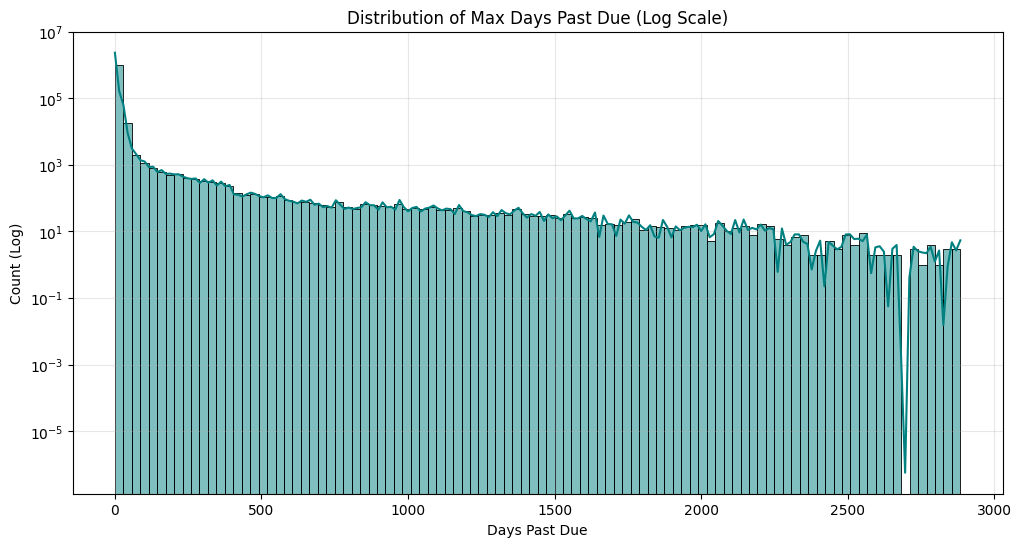

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(ins_final_summary['INS_INS_DPD_MAX'].dropna(), bins=100, kde=True, color='teal')
plt.yscale('log')
plt.title('Distribution of Max Days Past Due (Log Scale)')
plt.xlabel('Days Past Due')
plt.ylabel('Count (Log)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd

prev_app = pd.read_csv('../data/raw/previous_application.csv')

ins_final_summary.columns = [
    '_'.join(col).strip() if isinstance(col, tuple) else col 
    for col in ins_final_summary.columns
]

if 'SK_ID_PREV' not in ins_final_summary.columns:
    ins_final_summary = ins_final_summary.reset_index()

In [78]:
prev_with_ins = prev_app.merge(ins_final_summary, on='SK_ID_PREV', how='left')

print("-" * 30)
print(f"Prev App Row Count    : {prev_app.shape[0]}")
print(f"Merged Table Shape    : {prev_with_ins.shape}")
print("-" * 30)

------------------------------
Prev App Row Count    : 1670214
Merged Table Shape    : (1670214, 64)
------------------------------


### POS CASH Balance

In [84]:
from src.preprocessing import get_column_descriptions

pos_cash_metadata = get_column_descriptions('POS_CASH_balance.csv')
display(pos_cash_metadata)

,Row,Description,Special
142,SK_ID_PREV,"ID of previous credit in Home Credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",NaN
143,SK_ID_CURR,ID of loan in our sample,NaN
144,MONTHS_BALANCE,"Month of balance relative to application date (-1 means the information to the freshest monthly snapshot, 0 means the information at application - often it will be the same as -1 as many banks are not updating the information to Credit Bureau regularly )",time only relative to the application
145,CNT_INSTALMENT,Term of previous credit (can change over time),NaN
146,CNT_INSTALMENT_FUTURE,Installments left to pay on the previous credit,NaN
147,NAME_CONTRACT_STATUS,Contract status during the month,NaN
148,SK_DPD,DPD (days past due) during the month of previous credit,NaN
149,SK_DPD_DEF,DPD during the month with tolerance (debts with low loan amounts are ignored) of the previous credit,NaN


In [85]:
pos_cash_raw = pd.read_csv('../data/raw/POS_CASH_balance.csv')

display(pos_cash_raw.head())

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [88]:
print(f"POS Summary Shape: {pos_cash_raw.shape}")

POS Summary Shape: (10001358, 8)


In [87]:
from src.aggregation import aggregate_pos_cash

pos_prev_summary = aggregate_pos_cash(pos_cash_raw)

print(f"POS Summary Shape: {pos_prev_summary.shape}")

POS Summary Shape: (936325, 32)


In [89]:
prev_with_pos = prev_with_ins.merge(pos_prev_summary, on='SK_ID_PREV', how='left')

print(f"Prev Table Shape: {prev_with_pos.shape}")

Prev Table Shape: (1670214, 95)


### Credit Card Balance

In [90]:
from src.preprocessing import get_column_descriptions

credit_card_balance_raw = get_column_descriptions('credit_card_balance.csv')
display(credit_card_balance_raw)

,Row,Description,Special
150,SK_ID_PREV,"ID of previous credit in Home credit related to loan in our sample. (One loan in our sample can have 0,1,2 or more previous loans in Home Credit)",hashed
151,SK_ID_CURR,ID of loan in our sample,hashed
152,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application
153,AMT_BALANCE,Balance during the month of previous credit,NaN
154,AMT_CREDIT_LIMIT_ACTUAL,Credit card limit during the month of the previous credit,NaN
155,AMT_DRAWINGS_ATM_CURRENT,Amount drawing at ATM during the month of the previous credit,NaN
156,AMT_DRAWINGS_CURRENT,Amount drawing during the month of the previous credit,NaN
157,AMT_DRAWINGS_OTHER_CURRENT,Amount of other drawings during the month of the previous credit,NaN
158,AMT_DRAWINGS_POS_CURRENT,Amount drawing or buying goods during the month of the previous credit,NaN
159,AMT_INST_MIN_REGULARITY,Minimal installment for this month of the previous credit,NaN


In [91]:
import pandas as pd
import numpy as np

cc_bal = pd.read_csv('../data/raw/credit_card_balance.csv')

print(f"Credit Card Balance shape: {cc_bal.shape}")

Credit Card Balance shape: (3840312, 23)


In [ ]:
# Correlation within the Receivable Cluster
receivable_cols = ['AMT_RECIVABLE', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_TOTAL_RECEIVABLE']
receivable_corr = cc_bal[receivable_cols].corr()

print("--- Receivable Cluster Correlation Matrix ---")
print(receivable_corr)

# Check for near-perfect correlations (> 0.99)
# If correlation is almost 1.0, we can drop the redundant ones in agg_logic

--- Receivable Cluster Correlation Matrix ---
                          AMT_RECIVABLE  AMT_RECEIVABLE_PRINCIPAL  AMT_TOTAL_RECEIVABLE
AMT_RECIVABLE                  1.000000                  0.999727              0.999995
AMT_RECEIVABLE_PRINCIPAL       0.999727                  1.000000              0.999702
AMT_TOTAL_RECEIVABLE           0.999995                  0.999702              1.000000


In [ ]:
# Payment Current vs. Payment Total
payment_cols = ['AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT']

# Calculate correlation
payment_corr = cc_bal[payment_cols].corr()

payment_diff = (cc_bal['AMT_PAYMENT_TOTAL_CURRENT'] - cc_bal['AMT_PAYMENT_CURRENT']).abs().mean()

print("--- Payment Overlap Analysis ---")
print(f"Correlation between Current and Total Payment:\n{payment_corr}\n")
print(f"Mean Absolute Difference between payments: {payment_diff:.4f}")

--- Payment Overlap Analysis ---
Correlation between Current and Total Payment:
                           AMT_PAYMENT_CURRENT  AMT_PAYMENT_TOTAL_CURRENT
AMT_PAYMENT_CURRENT                   1.000000                   0.994764
AMT_PAYMENT_TOTAL_CURRENT             0.994764                   1.000000

Mean Absolute Difference between payments: 794.6965


In [ ]:
# Sparsity check for 'Other' type drawings
other_cols = ['AMT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT']

print("--- 'Other' Features Sparsity Analysis ---")
for col in other_cols:
    # Calculate percentage of rows where value is greater than zero
    non_zero_share = (cc_bal[col] > 0).sum() / len(cc_bal) * 100
    print(f"{col} - Percentage of non-zero entries: %{non_zero_share:.4f}")

# If the percentage is extremely low (e.g., < 0.1%), it's likely safe to exclude them

--- 'Other' Features Sparsity Analysis ---
AMT_DRAWINGS_OTHER_CURRENT - Percentage of non-zero entries: %0.3211
CNT_DRAWINGS_OTHER_CURRENT - Percentage of non-zero entries: %0.3335


In [105]:
from src.aggregation import aggregate_credit_card

cc_prev_summary = aggregate_credit_card(cc_bal)

print(f"Aggregated CC Shape: {cc_prev_summary.shape}")

Aggregated CC Shape: (104307, 54)


In [109]:
prev_ultimate = prev_with_pos.merge(
    cc_prev_summary.drop(columns=['SK_ID_CURR']), 
    on='SK_ID_PREV', 
    how='left'
)

filled_rows = prev_ultimate['CC_AMT_BALANCE_MEAN'].notnull().sum()
print(f"Kredi Kartı verisiyle dolan satır sayısı: {filled_rows}")

Kredi Kartı verisiyle dolan satır sayısı: 92935


In [110]:
prev_ultimate = prev_ultimate.loc[:, ~prev_ultimate.columns.duplicated()]

### Prev-App

In [115]:
print(f"Total Rows: {prev_ultimate.shape[0]:,}")
print(f"Total Columns: {prev_ultimate.shape[1]}")
print(f"Memory Usage: {prev_ultimate.memory_usage().sum() / 1024**2:.2f} MB")

non_numeric = prev_ultimate.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric columns: {non_numeric}") 
# Note: SK_ID_CURR and SK_ID_PREV should be here, but nothing else.

Total Rows: 1,670,214
Total Columns: 147
Memory Usage: 1873.18 MB
Non-numeric columns: ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']


In [120]:
# 2. Null Analysis
null_counts = prev_ultimate.isnull().mean() * 100
null_summary = null_counts.sort_values(ascending=False).head(500)

print("--- Top 100 Columns with Most Missing Values (%) ---")
print(null_summary)

# Logic: High null rates in CC columns are expected since not every loan is a Credit Card.

--- Top 100 Columns with Most Missing Values (%) ---
RATE_INTEREST_PRIMARY                      99.643698
RATE_INTEREST_PRIVILEGED                   99.643698
CC_AMT_DRAWINGS_ATM_CURRENT_MAX            96.275387
CC_AMT_DRAWINGS_POS_CURRENT_MAX            96.275387
CC_CNT_DRAWINGS_ATM_CURRENT_MAX            96.275387
CC_CNT_DRAWINGS_POS_CURRENT_MAX            96.275387
CC_CC_UTILIZATION_VAR                      94.478971
CC_AMT_BALANCE_VAR                         94.478971
CC_CNT_INSTALMENT_MATURE_CUM_MAX           94.435743
CC_AMT_PAYMENT_TOTAL_CURRENT_MAX           94.435743
CC_AMT_TOTAL_RECEIVABLE_MAX                94.435743
CC_CNT_DRAWINGS_POS_CURRENT_SUM            94.435743
CC_AMT_DRAWINGS_CURRENT_MAX                94.435743
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM           94.435743
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN          94.435743
CC_AMT_INST_MIN_REGULARITY_MAX             94.435743
CC_AMT_INST_MIN_REGULARITY_MEAN            94.435743
CC_AMT_TOTAL_RECEIVABLE_MEAN               94.

In [ ]:
portfolio_counts = prev_ultimate['NAME_PORTFOLIO'].value_counts()
portfolio_percent = prev_ultimate['NAME_PORTFOLIO'].value_counts(normalize=True) * 100

portfolio_report = pd.DataFrame({
    'Count': portfolio_counts,
    'Percentage (%)': portfolio_percent
})

print("--- NAME_PORTFOLIO Distribution ---")
print(portfolio_report)

--- NAME_PORTFOLIO Distribution ---
                 Count  Percentage (%)
NAME_PORTFOLIO                        
POS             691011       41.372603
Cash            461563       27.634962
XNA             372230       22.286366
Cards           144985        8.680624
Cars               425        0.025446


In [116]:
print(f"Prev-Pos ID Type: {prev_with_pos['SK_ID_PREV'].dtype}")
print(f"CC Summary ID Type: {cc_prev_summary['SK_ID_PREV'].dtype}")

set_prev = set(prev_with_pos['SK_ID_PREV'])
set_cc = set(cc_prev_summary['SK_ID_PREV'])
intersect = set_prev.intersection(set_cc)

print(f"CC table ID count: {len(set_cc)}")
print(f"Matched ID count: {len(intersect)}")

Prev-Pos ID Type: int64
CC Summary ID Type: int64
CC table ID count: 104307
Matched ID count: 92935


In [117]:
# 3. ID Integrity Check
row_count = len(prev_ultimate)
unique_loans = prev_ultimate['SK_ID_PREV'].nunique()
unique_customers = prev_ultimate['SK_ID_CURR'].nunique()

print(f"Row Count: {row_count}")
print(f"Unique Loans (SK_ID_PREV): {unique_loans}")
print(f"Unique Customers (SK_ID_CURR): {unique_customers}")

if row_count == unique_loans:
    print("SUCCESS: Data is perfectly at Loan-level (1 row per SK_ID_PREV).")
else:
    print("WARNING: Data is duplicated! Check your merge keys.")

Row Count: 1670214
Unique Loans (SK_ID_PREV): 1670214
Unique Customers (SK_ID_CURR): 334359
SUCCESS: Data is perfectly at Loan-level (1 row per SK_ID_PREV).


In [118]:
# 4. Constant Columns Check
# Finding columns where all values are the same (standard deviation is 0)
numeric_df = prev_ultimate.select_dtypes(include=[np.number])
constant_cols = [col for col in numeric_df.columns if numeric_df[col].std() == 0]

print(f"Constant columns found: {len(constant_cols)}")
if len(constant_cols) > 0:
    print(f"Recommended to drop: {constant_cols}")

Constant columns found: 0


In [119]:
from src.preprocessing import one_hot_encoder

prev_ultimate_ohe, cat_cols = one_hot_encoder(prev_ultimate, nan_as_category=True)

In [ ]:
import os
import gc

PROCESSED_DATA_PATH = '../data/processed/'
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print("Saving prev_ultimate_ohe to disk (CSV format)... This might take a few minutes.")
prev_ultimate_ohe.to_csv(os.path.join(PROCESSED_DATA_PATH, 'prev_ultimate_ohe.csv'), index=False)

Saving prev_ultimate_ohe to disk (CSV format)... This might take a few minutes.
